# Hyperparameter tuning techniques: controlled comparison

This notebook recreates the Chapter 10 grid/random/Bayesian comparison under the thesis validation protocol. It deliberately uses one series (US unemployment), one model (LightGBM), one original-target representation, the same three expanding Rep-Holdout-O folds, and the same 64-configuration budget for every method. A global panel is unnecessary for comparing search policies and would mainly multiply the cost of each objective evaluation.

The experiment compares both the lowest validation error obtained and how that error changes as more configurations are tried. Bayesian optimization uses the results of completed trials to choose later configurations, but it is not guaranteed to win every finite run.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'thesis').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from thesis.data_preparation import create_train_val_test_splits, load_dataset
from thesis.hyperparameter_search import (
    SEARCH_BOUNDS,
    comparison_folds,
    grid_configurations,
    random_configurations,
    run_configuration_sequence,
    run_tpe_search,
    summarize_searches,
)
from thesis.reporting import IMAGES_DIR, publication_latex

SEED = 67
DATASET_NAME = 'unemployment_us'
SEARCH_BUDGET = 64
N_SPLITS = 3
HORIZON = 12
TPE_STARTUP_TRIALS = 5
USE_CACHED_RESULTS = True
SAVE_FIGURES = True
FIGURE_FORMAT = 'jpg'

METRICS_DIR = REPO_ROOT / 'thesis/metrics/hyperparameter_search'
RESULTS_DIR = REPO_ROOT / 'thesis/results'
FIGURE_DIR = IMAGES_DIR / 'hyperparameter_search_comparison'
for directory in (METRICS_DIR, RESULTS_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

## Common data and validation objective

Only the fitting sample through 2023 is used. Each candidate configuration is scored by mean recursive 12-month RMSE across three non-overlapping expanding temporal holdouts. The 2024 model-selection validation block and 2025 test observations are never used in this methodological comparison.

In [3]:
raw, config = load_dataset(DATASET_NAME, 'manual')
ts_train, _, _, id_col, time_col, target_col = create_train_val_test_splits(
    raw, config, 'manual'
)
lags = config['ml_lags']
folds = comparison_folds(
    ts_train, lags=lags, horizon=HORIZON,
    n_splits=N_SPLITS, time_col=time_col,
)

fold_audit = pd.DataFrame([
    {
        'Fold': fold_number,
        'Training start': fit_fold[time_col].min(),
        'Training end': fit_fold[time_col].max(),
        'Validation start': validation_fold[time_col].min(),
        'Validation end': validation_fold[time_col].max(),
        'Validation months': validation_fold[time_col].nunique(),
    }
    for fold_number, (fit_fold, validation_fold) in enumerate(folds, start=1)
])
display(fold_audit)

,Fold,Training start,Training end,Validation start,Validation end,Validation months
0,1,1948-01-01,2020-12-01,2021-01-01,2021-12-01,12
1,2,1948-01-01,2021-12-01,2022-01-01,2022-12-01,12
2,3,1948-01-01,2022-12-01,2023-01-01,2023-12-01,12


## Grid search

Grid search evaluates a fixed $4\times4\times4$ lattice: learning rate, number of leaves, and minimum child observations each receive four levels. Its strength is deterministic coverage of that lattice; its weakness is that resolution grows exponentially with the number of tuned dimensions.

In [4]:
grid_path = METRICS_DIR / 'grid_search_trials.csv'
if USE_CACHED_RESULTS and grid_path.exists() and len(pd.read_csv(grid_path)) == SEARCH_BUDGET:
    grid_trials = pd.read_csv(grid_path)
else:
    grid_candidates = grid_configurations()
    if len(grid_candidates) != SEARCH_BUDGET:
        raise ValueError('The grid must match the common search budget')
    grid_trials = run_configuration_sequence(
        'Grid search', grid_candidates, folds,
        lags=lags, seed=SEED, id_col=id_col,
        time_col=time_col, target_col=target_col,
        freq=config['freq'],
    )
    grid_trials.to_csv(grid_path, index=False)
display(grid_trials.sort_values('RMSE').head())

,Method,Trial,RMSE,Best RMSE,Trial Time,Cumulative Time,Parameters
28,Grid search,29,0.537130,0.537130,0.167017,10.625967,"{""learning_rate"": 0.013572088082974531, ""min_c..."
31,Grid search,32,0.645070,0.537130,0.192666,11.193740,"{""learning_rate"": 0.013572088082974531, ""min_c..."
29,Grid search,30,0.645070,0.537130,0.189076,10.815043,"{""learning_rate"": 0.013572088082974531, ""min_c..."
30,Grid search,31,0.645070,0.537130,0.186031,11.001074,"{""learning_rate"": 0.013572088082974531, ""min_c..."
25,Grid search,26,0.728279,0.728279,0.344701,9.973129,"{""learning_rate"": 0.013572088082974531, ""min_c..."


## Random search

Random search draws 64 independent configurations from the same numerical bounds. Unlike the $4\times4\times4$ grid, the learning rate is sampled log-uniformly and the two integer dimensions can take every value in their bounded ranges.

In [5]:
random_path = METRICS_DIR / 'random_search_trials.csv'
if USE_CACHED_RESULTS and random_path.exists() and len(pd.read_csv(random_path)) == SEARCH_BUDGET:
    random_trials = pd.read_csv(random_path)
else:
    random_trials = run_configuration_sequence(
        'Random search', random_configurations(SEARCH_BUDGET, SEED), folds,
        lags=lags, seed=SEED, id_col=id_col,
        time_col=time_col, target_col=target_col,
        freq=config['freq'],
    )
    random_trials.to_csv(random_path, index=False)
display(random_trials.sort_values('RMSE').head())

,Method,Trial,RMSE,Best RMSE,Trial Time,Cumulative Time,Parameters
21,Random search,22,0.365187,0.365187,0.206620,8.157938,"{""learning_rate"": 0.03307130957698138, ""min_ch..."
30,Random search,31,0.411854,0.365187,0.277103,11.443779,"{""learning_rate"": 0.019156576462823593, ""min_c..."
28,Random search,29,0.423296,0.365187,0.415790,10.936949,"{""learning_rate"": 0.008026730149167403, ""min_c..."
12,Random search,13,0.434832,0.434832,0.251269,4.595563,"{""learning_rate"": 0.008368832662731383, ""min_c..."
53,Random search,54,0.518716,0.365187,0.207911,20.057275,"{""learning_rate"": 0.026412332615631872, ""min_c..."


## Bayesian optimization with Optuna/TPE

The first five trials are startup observations. TPE then compares parameter values from the lower-error trials with values from the remaining trials and gives greater probability to combinations associated with lower validation RMSE, while retaining some exploration. The fitted forecasting model and validation folds remain identical to the other two methods.

In [6]:
bayesian_path = METRICS_DIR / 'bayesian_search_trials.csv'
if USE_CACHED_RESULTS and bayesian_path.exists() and len(pd.read_csv(bayesian_path)) == SEARCH_BUDGET:
    bayesian_trials = pd.read_csv(bayesian_path)
else:
    bayesian_trials = run_tpe_search(
        SEARCH_BUDGET, folds, lags=lags, seed=SEED,
        startup_trials=TPE_STARTUP_TRIALS,
        id_col=id_col, time_col=time_col,
        target_col=target_col, freq=config['freq'],
    )
    bayesian_trials.to_csv(bayesian_path, index=False)
display(bayesian_trials.sort_values('RMSE').head())

,Method,Trial,RMSE,Best RMSE,Trial Time,Cumulative Time,Parameters
51,Bayesian optimization,52,0.334671,0.334671,0.205650,13.733950,"{""learning_rate"": 0.02236931193436912, ""min_ch..."
30,Bayesian optimization,31,0.419034,0.419034,0.209767,8.860317,"{""learning_rate"": 0.02830482316883904, ""min_ch..."
26,Bayesian optimization,27,0.420864,0.420864,0.262873,7.940854,"{""learning_rate"": 0.009400787811362922, ""min_c..."
61,Bayesian optimization,62,0.420872,0.334671,0.201851,16.475639,"{""learning_rate"": 0.014907829084927694, ""min_c..."
59,Bayesian optimization,60,0.424957,0.334671,0.215459,16.064120,"{""learning_rate"": 0.01455968784393926, ""min_ch..."


## Hyperparameter tuning techniques: comparison

The two-panel convergence figure compares the lowest RMSE reached after each evaluation and after the corresponding cumulative fitting time. A separate full-width violin figure combines density, embedded box plots, and individual points for every tried configuration.

,Method,Best RMSE,Best Trial,Trials,Fold Fits,Time Elapsed,Best Parameters
0,Bayesian optimization,0.334671,52,64,192,16.898679,"{""learning_rate"": 0.02236931193436912, ""min_ch..."
1,Random search,0.365187,22,64,192,24.363827,"{""learning_rate"": 0.03307130957698138, ""min_ch..."
2,Grid search,0.537130,29,64,192,22.362736,"{""learning_rate"": 0.013572088082974531, ""min_c..."


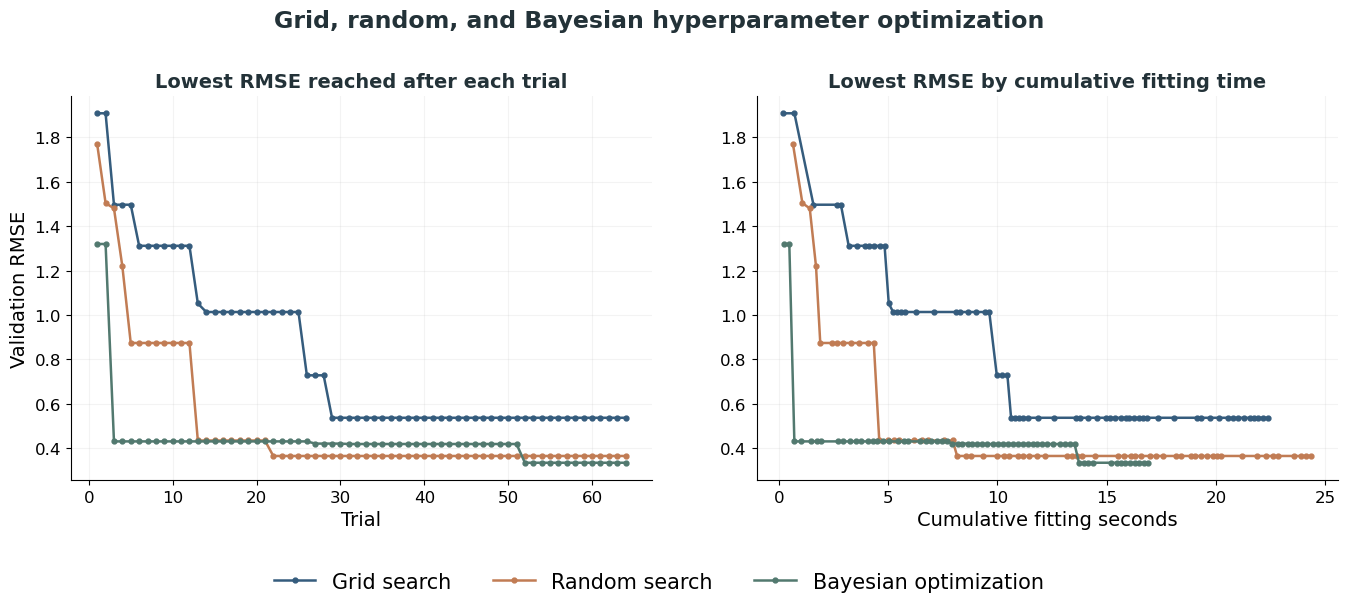

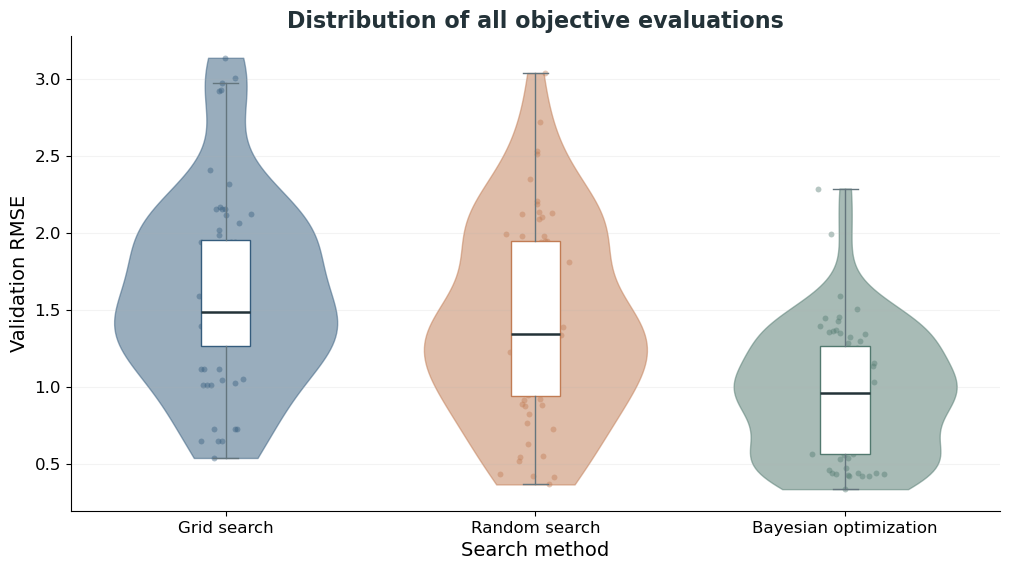

: 

In [ ]:
all_trials = pd.concat(
    [grid_trials, random_trials, bayesian_trials], ignore_index=True
)
summary = summarize_searches(all_trials, n_splits=N_SPLITS)
display(summary)

all_trials.to_csv(METRICS_DIR / 'all_search_trials.csv', index=False)
summary.to_csv(METRICS_DIR / 'search_method_summary.csv', index=False)
(RESULTS_DIR / 'hyperparameter_search_comparison.tex').write_text(
    publication_latex(
        summary.drop(columns=['Best Parameters']),
        caption=(
            'US unemployment LightGBM hyperparameter-search comparison. Every method '
            f'uses {SEARCH_BUDGET} configurations and three expanding twelve-month '
            'Rep-Holdout-O folds.'
        ),
        short_caption='US unemployment hyperparameter-search comparison',
        label='tab:hyperparameter-search-comparison',
        float_format=lambda value: f'{value:.4f}',
    ),
    encoding='utf-8',
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.2))
colors = {
    'Grid search': '#355C7D',
    'Random search': '#C17C54',
    'Bayesian optimization': '#52796F',
}
method_order = list(all_trials['Method'].drop_duplicates())
for method, group in all_trials.groupby('Method', sort=False):
    group = group.sort_values('Trial')
    axes[0].plot(
        group['Trial'], group['Best RMSE'], marker='o', markersize=3.5,
        linewidth=1.8, color=colors[method], label=method,
    )
    axes[1].plot(
        group['Cumulative Time'], group['Best RMSE'], marker='o',
        markersize=3.5, linewidth=1.8, color=colors[method], label=method,
    )

titles = (
    'Lowest RMSE reached after each trial',
    'Lowest RMSE by cumulative fitting time',
)
for axis, title in zip(axes, titles):
    axis.set_title(title, fontsize=14, weight='bold', color='#233238')
    axis.grid(alpha=0.14)
    axis.spines[['top', 'right']].set_visible(False)
    axis.tick_params(axis='both', labelsize=12)
axes[0].set(xlabel='Trial', ylabel='Validation RMSE')
axes[1].set(xlabel='Cumulative fitting seconds')
for axis in axes:
    axis.xaxis.label.set_size(14)
    axis.yaxis.label.set_size(14)
fig.legend(
    *axes[0].get_legend_handles_labels(), loc='lower center',
    ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.01), fontsize=15,
)
fig.suptitle(
    'Grid, random, and Bayesian hyperparameter optimization',
    fontsize=17, weight='bold', color='#233238',
)
fig.subplots_adjust(left=0.08, right=0.985, top=0.84, bottom=0.22, wspace=0.18)
if SAVE_FIGURES:
    fig.savefig(
        FIGURE_DIR / f'hyperparameter_search_convergence.{FIGURE_FORMAT}',
        dpi=320, bbox_inches='tight', facecolor='white',
        pil_kwargs={'quality': 95, 'subsampling': 0},
    )
plt.show()

distributions = [
    all_trials.loc[all_trials['Method'] == method, 'RMSE'].to_numpy()
    for method in method_order
]
distribution_fig, distribution_axis = plt.subplots(figsize=(10.5, 6.5))
violins = distribution_axis.violinplot(
    distributions, positions=np.arange(1, len(method_order) + 1),
    widths=0.72, showmeans=False, showmedians=False, showextrema=False,
)
for body, method in zip(violins['bodies'], method_order):
    body.set_facecolor(colors[method])
    body.set_edgecolor(colors[method])
    body.set_alpha(0.50)
box = distribution_axis.boxplot(
    distributions, positions=np.arange(1, len(method_order) + 1),
    widths=0.16, patch_artist=True, showfliers=False,
    medianprops={'color': '#233238', 'linewidth': 1.8},
    whiskerprops={'color': '#64757D'}, capprops={'color': '#64757D'},
)
for patch, method in zip(box['boxes'], method_order):
    patch.set_facecolor('white')
    patch.set_edgecolor(colors[method])
rng = np.random.default_rng(SEED)
for position, (method, values) in enumerate(zip(method_order, distributions), start=1):
    jitter = rng.normal(0, 0.045, size=len(values))
    distribution_axis.scatter(
        np.full(len(values), position) + jitter, values,
        s=18, color=colors[method], alpha=0.42, linewidths=0,
    )
distribution_axis.set_title(
    'Distribution of all objective evaluations',
    fontsize=16, weight='bold', color='#233238',
)
distribution_axis.set(
    ylabel='Validation RMSE', xlabel='Search method',
)
distribution_axis.xaxis.label.set_size(14)
distribution_axis.yaxis.label.set_size(14)
distribution_axis.tick_params(axis='both', labelsize=12)
distribution_axis.set_xticks(
    np.arange(1, len(method_order) + 1), method_order,
)
distribution_axis.grid(axis='y', alpha=0.14)
distribution_axis.spines[['top', 'right']].set_visible(False)
distribution_fig.subplots_adjust(left=0.10, right=0.985, top=0.88, bottom=0.15)
if SAVE_FIGURES:
    distribution_fig.savefig(
        FIGURE_DIR / f'hyperparameter_search_distribution.{FIGURE_FORMAT}',
        dpi=320, bbox_inches='tight', facecolor='white',
        pil_kwargs={'quality': 95, 'subsampling': 0},
    )
plt.show()

## Interpretation guardrails

- Each method performs $64\times3=192$ LightGBM fits. No model-selection validation or test observation is used.
- Grid search evaluates a coarse lattice; random search and TPE can propose intermediate values inside the same bounds.
- TPE uses five startup observations and has sequential proposal overhead, but that overhead is normally small relative to fitting an expensive model.
- Bayesian optimization is supported here if it obtains a lower validation RMSE under the common budget. One realization cannot establish universal dominance.
- The comparison uses the Original target to isolate the search policy from the additional cost and decisions of AutoStationary transformation.